<a href="https://colab.research.google.com/github/indra1236/indra/blob/main/UTS_Pengolahan_Citra_Digital_Soal_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Saving b49f836639399fda46b9b2b818fa7af1.jpg to b49f836639399fda46b9b2b818fa7af1.jpg
Mean Pixel:
Original: 186.6169936643431
LPF     : 186.6173739514414
HPF     : 7.797491581994329
BPF     : 186.26173167237712


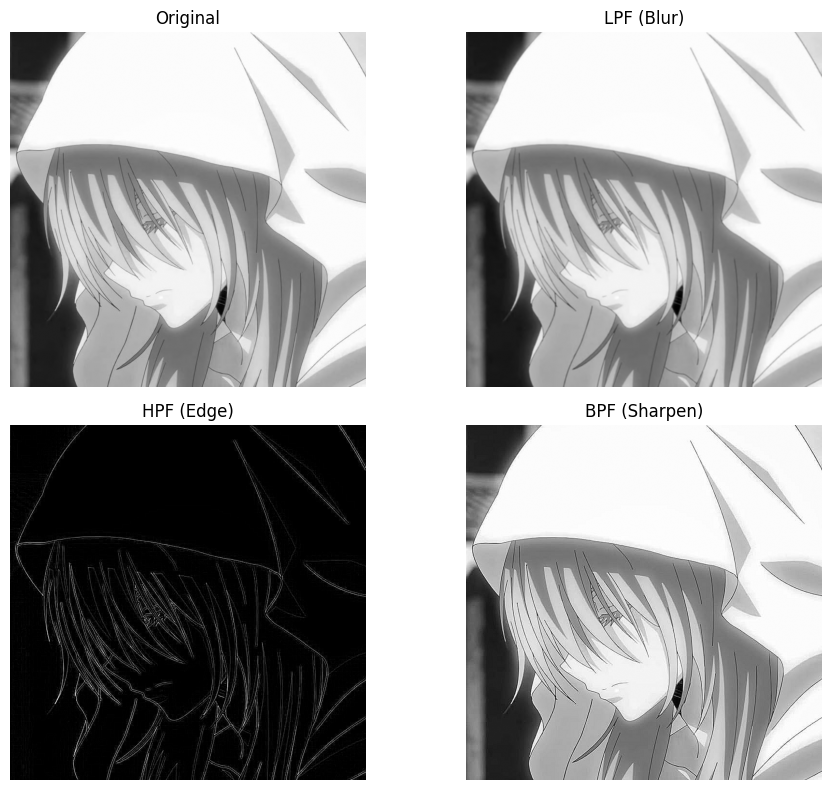

In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from google.colab import files

# Upload gambar
uploaded = files.upload()

# Ambil nama file
image_path = list(uploaded.keys())[0]

# Baca gambar
img = cv2.imread(image_path)
img_gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

# =====================
# Definisi Kernel
# =====================

# Low Pass Filter (Blur)
kernel_lpf = (1/9) * np.array([[1,1,1],
                               [1,1,1],
                               [1,1,1]])

# High Pass Filter (Edge Detection)
kernel_hpf = np.array([[-1,-1,-1],
                       [-1, 8,-1],
                       [-1,-1,-1]])

# Band Pass Filter (Sharpening)
kernel_bpf = np.array([[0,-1,0],
                       [-1,5,-1],
                       [0,-1,0]])

# =====================
# Proses Konvolusi
# =====================

lpf = cv2.filter2D(img_gray, -1, kernel_lpf)
hpf = cv2.filter2D(img_gray, -1, kernel_hpf)
bpf = cv2.filter2D(img_gray, -1, kernel_bpf)

# =====================
# Hitung Rata-rata Piksel
# =====================

mean_original = np.mean(img_gray)
mean_lpf = np.mean(lpf)
mean_hpf = np.mean(hpf)
mean_bpf = np.mean(bpf)

print("Mean Pixel:")
print(f"Original: {mean_original}")
print(f"LPF     : {mean_lpf}")
print(f"HPF     : {mean_hpf}")
print(f"BPF     : {mean_bpf}")

# =====================
# Tampilkan Gambar
# =====================

plt.figure(figsize=(10,8))

plt.subplot(2,2,1)
plt.title("Original")
plt.imshow(img_gray, cmap='gray')
plt.axis('off')

plt.subplot(2,2,2)
plt.title("LPF (Blur)")
plt.imshow(lpf, cmap='gray')
plt.axis('off')

plt.subplot(2,2,3)
plt.title("HPF (Edge)")
plt.imshow(hpf, cmap='gray')
plt.axis('off')

plt.subplot(2,2,4)
plt.title("BPF (Sharpen)")
plt.imshow(bpf, cmap='gray')
plt.axis('off')

plt.tight_layout()
plt.show()